<a href="https://colab.research.google.com/github/SrilathaWeb/Data-Science-Cohort-20/blob/main/SQL_1_Chinook_project_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project SQL - Chinook


## Chinook data set

See the lecture on SQLite3 using the Chinook data set to set up the software, database, and tables, as well as for the links to ancillary information about the data set.


In [ ]:
import sqlite3 as db
import pandas as pd
from google.colab import output


In [ ]:
%%capture
%%bash
apt-get update
apt-get install -y sqlite3
pip install sqlite-web


In [ ]:
!sqlite3 --help


Usage: sqlite3 [OPTIONS] FILENAME [SQL]
FILENAME is the name of an SQLite database. A new database is created
if the file does not previously exist.
OPTIONS include:
   -A ARGS...           run ".archive ARGS" and exit
   -append              append the database to the end of the file
   -ascii               set output mode to 'ascii'
   -bail                stop after hitting an error
   -batch               force batch I/O
   -box                 set output mode to 'box'
   -column              set output mode to 'column'
   -cmd COMMAND         run "COMMAND" before reading stdin
   -csv                 set output mode to 'csv'
   -deserialize         open the database using sqlite3_deserialize()
   -echo                print commands before execution
   -init FILENAME       read/process named file
   -[no]header          turn headers on or off
   -help                show this message
   -html                set output mode to HTML
   -interactive         force interactive I/O
   -j

In [ ]:
!sqlite3 --version


3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1


In [ ]:
%%bash
[ -f chinook.zip ] ||
  curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip
unzip -l chinook.zip


Archive:  chinook.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   884736  2015-11-29 10:53   chinook.db
---------                     -------
   884736                     1 file


In [ ]:
!rm -f chinook.db


In [ ]:
!unzip -u chinook.zip


Archive:  chinook.zip
  inflating: chinook.db              


In [ ]:
!ls -la


total 1180
drwxr-xr-x 1 root root   4096 May  5 02:50 .
drwxr-xr-x 1 root root   4096 May  4 22:11 ..
-rw-r--r-- 1 root root 884736 Nov 29  2015 chinook.db
-rw-r--r-- 1 root root 305596 May  4 23:10 chinook.zip
drwxr-xr-x 4 root root   4096 Apr 16 13:28 .config
drwxr-xr-x 1 root root   4096 Apr 16 13:28 sample_data


In [ ]:
# Install the sqlite package for Ubuntu
# Download the Chinook sqlite database


In [ ]:
# Connect to a sqlite database and load a result set into a data frame
db_con = db.connect("chinook.db")


In [ ]:
# retriving table names from sqllite db
query = '''
 SELECT name FROM sqlite_master WHERE type='table';
'''

table_names = pd.read_sql_query( query , db_con)
table_names

,name
0,albums
1,sqlite_sequence
2,artists
3,customers
4,employees
5,genres
6,invoices
7,invoice_items
8,media_types
9,playlists


## Come up with questions about your data
Have a look at the Entity-Relation ( ER ) diagram to help come up with questions.

* What sort of information is in this dataset?
* How many records are there?
* How many different countries (states, counties, cities, etc) have records in this data set?


If you are stuck, here are some ideas for questions:
- https://github.com/LucasMcL/15-sql_queries_02-chinook/blob/master/README.md
- [Using the R language]( https://rpubs.com/enext777/636199 )
- [Search Google]( https://www.google.com/search?q=chinook+database+questions )



## Use SQL queries to pull specific information

Do NOT pull all the data and then filter using DataFrame methods etc. Make sure and use AT LEAST 13 of the 15 SQL options listed below. (You may have to get creative and come up with more questions to ask/answer.)


### Basic Queries


#### SELECT (with * and with column names)


In [ ]:
# Select the first 10 entries from the customers table
%%script sqlite3 --column --header chinook.db
select *
from customers
limit 10


CustomerId  FirstName  LastName     Company                                           Address                               City                 State  Country         PostalCode  Phone               Fax                 Email                     SupportRepId
----------  ---------  -----------  ------------------------------------------------  ------------------------------------  -------------------  -----  --------------  ----------  ------------------  ------------------  ------------------------  ------------
1           Luís       Gonçalves    Embraer - Empresa Brasileira de Aeronáutica S.A.  Av. Brigadeiro Faria Lima, 2170       São José dos Campos  SP     Brazil          12227-000   +55 (12) 3923-5555  +55 (12) 3923-5566  luisg@embraer.com.br      3           
2           Leonie     Köhler                                                         Theodor-Heuss-Straße 34               Stuttgart                   Germany         70174       +49 0711 2842222                        leo

#### WHERE


In [ ]:
# Select the  employee records where city = Calgary from the customers table
%%script sqlite3 --column --header chinook.db
select *
from customers where city = 'Prague'

CustomerId  FirstName  LastName     Company           Address        City    State  Country         PostalCode  Phone             Fax               Email                     SupportRepId
----------  ---------  -----------  ----------------  -------------  ------  -----  --------------  ----------  ----------------  ----------------  ------------------------  ------------
5           František  Wichterlová  JetBrains s.r.o.  Klanova 9/506  Prague         Czech Republic  14700       +420 2 4172 5555  +420 2 4172 5555  frantisekw@jetbrains.com  4           
6           Helena     Holý                           Rilská 3174/6  Prague         Czech Republic  14300       +420 2 4177 0449                    hholy@gmail.com           5           


#### AND


In [ ]:
# Select the  employee records where city = Calgary from the customers table
%%script sqlite3 --column --header chinook.db
select *
from customers
where city = 'Prague' and PostalCode = 14700

CustomerId  FirstName  LastName     Company           Address        City    State  Country         PostalCode  Phone             Fax               Email                     SupportRepId
----------  ---------  -----------  ----------------  -------------  ------  -----  --------------  ----------  ----------------  ----------------  ------------------------  ------------
5           František  Wichterlová  JetBrains s.r.o.  Klanova 9/506  Prague         Czech Republic  14700       +420 2 4172 5555  +420 2 4172 5555  frantisekw@jetbrains.com  4           


In [ ]:
# Select the  employee records where city = Calgary from the customers table
%%script sqlite3 --column --header chinook.db
select *
from customers c
inner join employees e on e.EmployeeId  = c.SupportRepId
where  SupportRepId  = 3 and c.country='USA'


CustomerId  FirstName  LastName  Company     Address                City       State  Country  PostalCode  Phone              Fax                Email               SupportRepId  EmployeeId  LastName  FirstName  Title                ReportsTo  BirthDate            HireDate             Address        City     State  Country  PostalCode  Phone              Fax                Email               
----------  ---------  --------  ----------  ---------------------  ---------  -----  -------  ----------  -----------------  -----------------  ------------------  ------------  ----------  --------  ---------  -------------------  ---------  -------------------  -------------------  -------------  -------  -----  -------  ----------  -----------------  -----------------  --------------------
18          Michelle   Brooks                627 Broadway           New York   NY     USA      10012-2612  +1 (212) 221-3546  +1 (212) 221-4679  michelleb@aol.com   3             3           Peacock   Jane 

#### OR


In [ ]:
# Select the  employee records where city = Calgary from the customers table
%%script sqlite3 --column --header chinook.db
select c.firstname, c.lastname, c.supportrepid, e.employeeid, e.firstname
from customers c
inner join employees e on e.EmployeeId  = c.SupportRepId
where  SupportRepId  = 3  or SupportRepId = 5


FirstName  LastName      SupportRepId  EmployeeId  FirstName
---------  ------------  ------------  ----------  ---------
Luís       Gonçalves     3             3           Jane     
François   Tremblay      3             3           Jane     
Roberto    Almeida       3             3           Jane     
Jennifer   Peterson      3             3           Jane     
Michelle   Brooks        3             3           Jane     
Tim        Goyer         3             3           Jane     
Frank      Ralston       3             3           Jane     
Robert     Brown         3             3           Jane     
Edward     Francis       3             3           Jane     
Ellie      Sullivan      3             3           Jane     
Fynn       Zimmermann    3             3           Jane     
Niklas     Schröder      3             3           Jane     
Wyatt      Girard        3             3           Jane     
Isabelle   Mercier       3             3           Jane     
Terhi      Hämäläinen   

In [ ]:
# Select the  employee records where city = Calgary from the customers table
%%script sqlite3 --column --header chinook.db
select c.firstname, c.lastname, c.supportrepid, e.employeeid, e.firstname
from customers c
inner join employees e on e.EmployeeId  = c.SupportRepId
where  SupportRepId  in(3,5)


FirstName  LastName      SupportRepId  EmployeeId  FirstName
---------  ------------  ------------  ----------  ---------
Luís       Gonçalves     3             3           Jane     
François   Tremblay      3             3           Jane     
Roberto    Almeida       3             3           Jane     
Jennifer   Peterson      3             3           Jane     
Michelle   Brooks        3             3           Jane     
Tim        Goyer         3             3           Jane     
Frank      Ralston       3             3           Jane     
Robert     Brown         3             3           Jane     
Edward     Francis       3             3           Jane     
Ellie      Sullivan      3             3           Jane     
Fynn       Zimmermann    3             3           Jane     
Niklas     Schröder      3             3           Jane     
Wyatt      Girard        3             3           Jane     
Isabelle   Mercier       3             3           Jane     
Terhi      Hämäläinen   

In [ ]:
# Select the  employee records where city = Calgary from the customers table
%%script sqlite3 --column --header chinook.db
select *
from customers where city in ( 'New York' , 'Edmonton')

CustomerId  FirstName  LastName  Company  Address         City      State  Country  PostalCode  Phone              Fax                Email               SupportRepId
----------  ---------  --------  -------  --------------  --------  -----  -------  ----------  -----------------  -----------------  ------------------  ------------
14          Mark       Philips   Telus    8210 111 ST NW  Edmonton  AB     Canada   T6G 2C7     +1 (780) 434-4554  +1 (780) 434-5565  mphilips12@shaw.ca  5           
18          Michelle   Brooks             627 Broadway    New York  NY     USA      10012-2612  +1 (212) 221-3546  +1 (212) 221-4679  michelleb@aol.com   3           


#### LIKE (with % or _ wildcard)


In [ ]:
# Select the  employee records where city = Calgary from the customers table
%%script sqlite3 --column --header chinook.db
select *
from employees
where title like 'Sales %'

EmployeeId  LastName  FirstName  Title                ReportsTo  BirthDate            HireDate             Address           City     State  Country  PostalCode  Phone              Fax                Email                   
----------  --------  ---------  -------------------  ---------  -------------------  -------------------  ----------------  -------  -----  -------  ----------  -----------------  -----------------  ------------------------
2           Edwards   Nancy      Sales Manager        1          1958-12-08 00:00:00  2002-05-01 00:00:00  825 8 Ave SW      Calgary  AB     Canada   T2P 2T3     +1 (403) 262-3443  +1 (403) 262-3322  nancy@chinookcorp.com   
3           Peacock   Jane       Sales Support Agent  2          1973-08-29 00:00:00  2002-04-01 00:00:00  1111 6 Ave SW     Calgary  AB     Canada   T2P 5M5     +1 (403) 262-3443  +1 (403) 262-6712  jane@chinookcorp.com    
4           Park      Margaret   Sales Support Agent  2          1947-09-19 00:00:00  2003-05-03 00:

In [ ]:
%%script sqlite3 --column --header chinook.db
select *
from employees
where title like 'Sal_s %'

EmployeeId  LastName  FirstName  Title                ReportsTo  BirthDate            HireDate             Address           City     State  Country  PostalCode  Phone              Fax                Email                   
----------  --------  ---------  -------------------  ---------  -------------------  -------------------  ----------------  -------  -----  -------  ----------  -----------------  -----------------  ------------------------
2           Edwards   Nancy      Sales Manager        1          1958-12-08 00:00:00  2002-05-01 00:00:00  825 8 Ave SW      Calgary  AB     Canada   T2P 2T3     +1 (403) 262-3443  +1 (403) 262-3322  nancy@chinookcorp.com   
3           Peacock   Jane       Sales Support Agent  2          1973-08-29 00:00:00  2002-04-01 00:00:00  1111 6 Ave SW     Calgary  AB     Canada   T2P 5M5     +1 (403) 262-3443  +1 (403) 262-6712  jane@chinookcorp.com    
4           Park      Margaret   Sales Support Agent  2          1947-09-19 00:00:00  2003-05-03 00:

In [ ]:
%%script sqlite3 --column --header chinook.db
select *
from employees
where title like 'IT _____'

EmployeeId  LastName  FirstName  Title     ReportsTo  BirthDate            HireDate             Address                      City        State  Country  PostalCode  Phone              Fax                Email                 
----------  --------  ---------  --------  ---------  -------------------  -------------------  ---------------------------  ----------  -----  -------  ----------  -----------------  -----------------  ----------------------
7           King      Robert     IT Staff  6          1970-05-29 00:00:00  2004-01-02 00:00:00  590 Columbia Boulevard West  Lethbridge  AB     Canada   T1K 5N8     +1 (403) 456-9986  +1 (403) 456-8485  robert@chinookcorp.com
8           Callahan  Laura      IT Staff  6          1968-01-09 00:00:00  2004-03-04 00:00:00  923 7 ST NW                  Lethbridge  AB     Canada   T1H 1Y8     +1 (403) 467-3351  +1 (403) 467-8772  laura@chinookcorp.com 


#### BETWEEN


In [ ]:
%%script sqlite3 --column --header chinook.db
select *
from employees
where HireDate  between '2002-05-01' and '2003-10-18'

EmployeeId  LastName  FirstName  Title                ReportsTo  BirthDate            HireDate             Address               City      State  Country  PostalCode  Phone              Fax                Email                   
----------  --------  ---------  -------------------  ---------  -------------------  -------------------  --------------------  --------  -----  -------  ----------  -----------------  -----------------  ------------------------
1           Adams     Andrew     General Manager                 1962-02-18 00:00:00  2002-08-14 00:00:00  11120 Jasper Ave NW   Edmonton  AB     Canada   T5K 2N1     +1 (780) 428-9482  +1 (780) 428-3457  andrew@chinookcorp.com  
2           Edwards   Nancy      Sales Manager        1          1958-12-08 00:00:00  2002-05-01 00:00:00  825 8 Ave SW          Calgary   AB     Canada   T2P 2T3     +1 (403) 262-3443  +1 (403) 262-3322  nancy@chinookcorp.com   
4           Park      Margaret   Sales Support Agent  2          1947-09-19 00:0

#### LIMIT



In [ ]:
%%script sqlite3 --column --header chinook.db
select *
from employees
where HireDate  between '2002-05-01' and '2003-10-18'
Limit 3

EmployeeId  LastName  FirstName  Title                ReportsTo  BirthDate            HireDate             Address              City      State  Country  PostalCode  Phone              Fax                Email                   
----------  --------  ---------  -------------------  ---------  -------------------  -------------------  -------------------  --------  -----  -------  ----------  -----------------  -----------------  ------------------------
1           Adams     Andrew     General Manager                 1962-02-18 00:00:00  2002-08-14 00:00:00  11120 Jasper Ave NW  Edmonton  AB     Canada   T5K 2N1     +1 (780) 428-9482  +1 (780) 428-3457  andrew@chinookcorp.com  
2           Edwards   Nancy      Sales Manager        1          1958-12-08 00:00:00  2002-05-01 00:00:00  825 8 Ave SW         Calgary   AB     Canada   T2P 2T3     +1 (403) 262-3443  +1 (403) 262-3322  nancy@chinookcorp.com   
4           Park      Margaret   Sales Support Agent  2          1947-09-19 00:00:00

### Sorting and Grouping


#### ORDER BY


In [ ]:
%%script sqlite3 --column --header chinook.db
select *
from employees
where HireDate  between '2002-05-01' and '2003-10-18'
order by BirthDate

EmployeeId  LastName  FirstName  Title                ReportsTo  BirthDate            HireDate             Address               City      State  Country  PostalCode  Phone              Fax                Email                   
----------  --------  ---------  -------------------  ---------  -------------------  -------------------  --------------------  --------  -----  -------  ----------  -----------------  -----------------  ------------------------
4           Park      Margaret   Sales Support Agent  2          1947-09-19 00:00:00  2003-05-03 00:00:00  683 10 Street SW      Calgary   AB     Canada   T2P 5G3     +1 (403) 263-4423  +1 (403) 263-4289  margaret@chinookcorp.com
2           Edwards   Nancy      Sales Manager        1          1958-12-08 00:00:00  2002-05-01 00:00:00  825 8 Ave SW          Calgary   AB     Canada   T2P 2T3     +1 (403) 262-3443  +1 (403) 262-3322  nancy@chinookcorp.com   
1           Adams     Andrew     General Manager                 1962-02-18 00:0

#### DISTINCT


In [ ]:
%%script sqlite3 --column --header chinook.db
select Distinct city
from customers

City               
-------------------
São José dos Campos
Stuttgart          
Montréal           
Oslo               
Prague             
Vienne             
Brussels           
Copenhagen         
São Paulo          
Rio de Janeiro     
Brasília           
Edmonton           
Vancouver          
Mountain View      
Redmond            
New York           
Cupertino          
Reno               
Orlando            
Boston             
Chicago            
Madison            
Fort Worth         
Tucson             
Salt Lake City     
Toronto            
Ottawa             
Halifax            
Winnipeg           
Yellowknife        
Lisbon             
Porto              
Berlin             
Frankfurt          
Paris              
Lyon               
Bordeaux           
Dijon              
Helsinki           
Budapest           
Dublin             
Rome               
Amsterdam          
Warsaw             
Madrid             
Stockholm          
London             
Edinburgh          


#### GROUP BY



In [ ]:
%%script sqlite3 --column --header chinook.db
select  e.firstname,e.lastname,e.employeeid, count(c.customerId)
from customers c
inner join employees e on e.employeeid = c.supportrepid
where e.EmployeeId  = 3
group by e.EmployeeId

FirstName  LastName  EmployeeId  count(c.customerId)
---------  --------  ----------  -------------------
Jane       Peacock   3           21                 


### Aggregates


#### MAX


In [ ]:
%%script sqlite3 --column --header chinook.db
select * from invoices limit 3

InvoiceId  CustomerId  InvoiceDate          BillingAddress           BillingCity  BillingState  BillingCountry  BillingPostalCode  Total
---------  ----------  -------------------  -----------------------  -----------  ------------  --------------  -----------------  -----
1          2           2009-01-01 00:00:00  Theodor-Heuss-Straße 34  Stuttgart                  Germany         70174              1.98 
2          4           2009-01-02 00:00:00  Ullevålsveien 14         Oslo                       Norway          0171               3.96 
3          8           2009-01-03 00:00:00  Grétrystraat 63          Brussels                   Belgium         1000               5.94 


In [ ]:
%%script sqlite3 --column --header chinook.db
select * from customers limit 3

CustomerId  FirstName  LastName   Company                                           Address                          City                 State  Country  PostalCode  Phone               Fax                 Email                  SupportRepId
----------  ---------  ---------  ------------------------------------------------  -------------------------------  -------------------  -----  -------  ----------  ------------------  ------------------  ---------------------  ------------
1           Luís       Gonçalves  Embraer - Empresa Brasileira de Aeronáutica S.A.  Av. Brigadeiro Faria Lima, 2170  São José dos Campos  SP     Brazil   12227-000   +55 (12) 3923-5555  +55 (12) 3923-5566  luisg@embraer.com.br   3           
2           Leonie     Köhler                                                       Theodor-Heuss-Straße 34          Stuttgart                   Germany  70174       +49 0711 2842222                        leonekohler@surfeu.de  5           
3           François   Tremblay 

In [ ]:
%%script sqlite3 --column --header chinook.db
select  c.customerid, c.firstname, c.lastname, max(total)
from customers c
inner join invoices i on c.CustomerId   = i.CustomerId
where i.CustomerId  = 2
group by i.customerid

CustomerId  FirstName  LastName  max(total)
----------  ---------  --------  ----------
2           Leonie     Köhler    13.86     


#### MIN


In [ ]:
%%script sqlite3 --column --header chinook.db
select  c.customerid, c.firstname, c.lastname, min(total)
from customers c
inner join invoices i on c.CustomerId   = i.CustomerId
where i.CustomerId  = 2
group by i.customerid

CustomerId  FirstName  LastName  min(total)
----------  ---------  --------  ----------
2           Leonie     Köhler    0.99      


#### SUM


In [ ]:
%%script sqlite3 --column --header chinook.db
select  c.customerid, c.firstname, c.lastname, sum(total)
from customers c
inner join invoices i on c.CustomerId   = i.CustomerId
where i.CustomerId  = 2
group by i.customerid

CustomerId  FirstName  LastName  sum(total)
----------  ---------  --------  ----------
2           Leonie     Köhler    37.62     


#### AVG


In [ ]:
%%script sqlite3 --column --header chinook.db
select  c.customerid, c.firstname, c.lastname, avg(total)
from customers c
inner join invoices i on c.CustomerId   = i.CustomerId
where i.CustomerId  = 2
group by i.customerid

CustomerId  FirstName  LastName  avg(total)      
----------  ---------  --------  ----------------
2           Leonie     Köhler    5.37428571428571


#### COUNT



In [ ]:
%%script sqlite3 --column --header chinook.db
select  c.customerid, c.firstname, c.lastname, count(total)
from customers c
inner join invoices i on c.CustomerId   = i.CustomerId
where i.CustomerId  = 2
group by i.customerid

CustomerId  FirstName  LastName  count(total)
----------  ---------  --------  ------------
2           Leonie     Köhler    7           


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



In [ ]:
# retriving table names from sqllite db
query = '''
  select
      e.FirstName || ' ' || e.LastName AS EmployeeName,
      SUM(i.Total) AS TotalSales
  from Employees e
  inner join Customers c ON e.EmployeeId = c.SupportRepId
  inner join Invoices i ON c.CustomerId = i.CustomerId
  group  by e.EmployeeId
  order by TotalSales DESC
'''

df_employee_sales = pd.read_sql_query( query , db_con)
df_employee_sales

,EmployeeName,TotalSales
0,Jane Peacock,833.04
1,Margaret Park,775.40
2,Steve Johnson,720.16


In [ ]:
country_query = """
SELECT Country, COUNT(CustomerId) AS Customers_Count
FROM Customers
GROUP BY Country
ORDER BY Customers_Count DESC LIMIT 10;
"""


df_customers_country = pd.read_sql_query( country_query , db_con)
df_customers_country

,Country,Customers_Count
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4
5,United Kingdom,3
6,Portugal,2
7,India,2
8,Czech Republic,2
9,Sweden,1


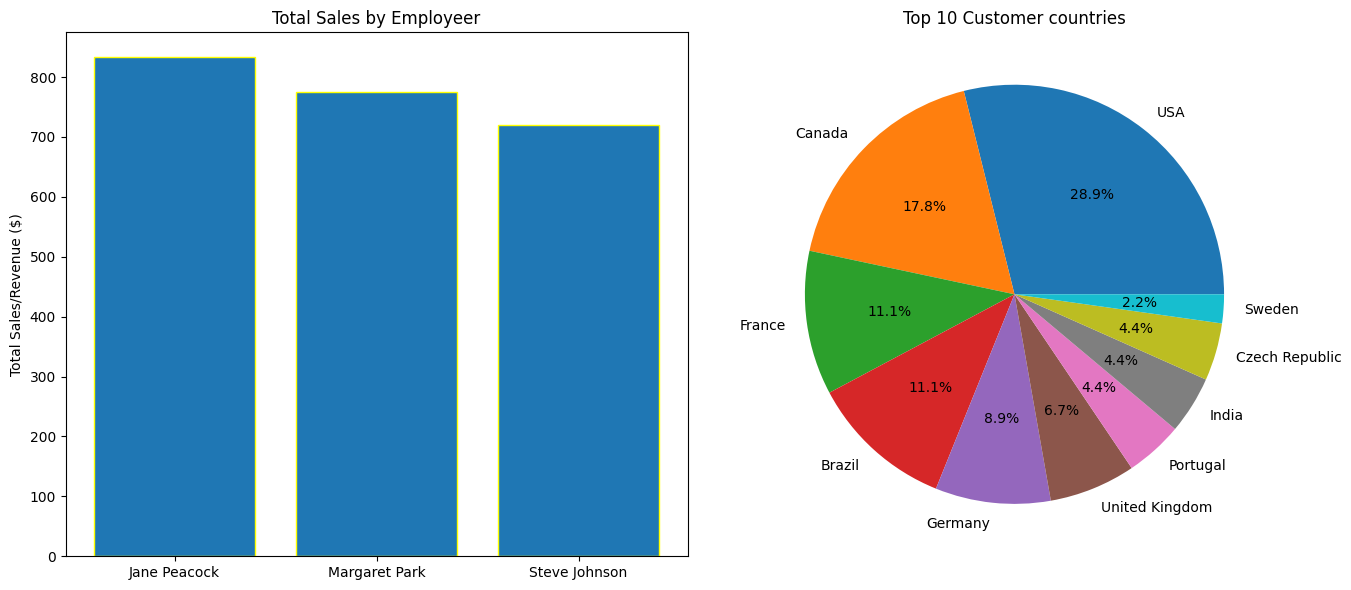

In [ ]:
import matplotlib.pyplot as plt


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(df_employee_sales['EmployeeName'],df_employee_sales['TotalSales'], edgecolor='yellow')
ax1.set_title('Total Sales by Employeer')
ax1.set_ylabel('Total Sales/Revenue ($)')

ax2.pie(df_customers_country['Customers_Count'], labels=df_customers_country['Country'],autopct='%1.1f%%')
ax2.set_title("Top 10 Customer countries")

plt.tight_layout()

plt.show()

## EXTRA CREDIT:
* Use a CTE
* Use a query that joins two or more tables.
* Make a model to see if you can predict something
* Come up with something else cool to do with your data


In [ ]:
query = """
with customermetrics as (
  select
    c.customerid, c.firstname || ' ' || c.lastname as customer_name, count(i.invoiceid) as invoice_count, sum(total) as total
  from Customers c
  inner join invoices i on c.customerid = i.CustomerId
  group by c.customerid
)
select * from customermetrics """

df_metrics = pd.read_sql_query(query,db_con)
df_metrics

,customerid,customer_name,invoice_count,total
0,1,Luís Gonçalves,7,39.62
1,2,Leonie Köhler,7,37.62
2,3,François Tremblay,7,39.62
3,4,Bjørn Hansen,7,39.62
4,5,František Wichterlová,7,40.62
5,6,Helena Holý,7,49.62
6,7,Astrid Gruber,7,42.62
7,8,Daan Peeters,7,37.62
8,9,Kara Nielsen,7,37.62
9,10,Eduardo Martins,7,37.62


In [ ]:
%%script sqlite3 --column --header chinook.db
select * from invoice_items limit 1

InvoiceLineId  InvoiceId  TrackId  UnitPrice  Quantity
-------------  ---------  -------  ---------  --------
1              1          2        0.99       1       


In [ ]:
%%script sqlite3 --column --header chinook.db
select
e.employeeid,
    e.firstname || ' ' || e.lastname AS employeename,
    c.firstname || ' ' || c.lastname AS customername,
    i.invoicedate, t.name as trackname, alb.title as albumtitle,
    art.name as artistname,mt.name  medianame ,
    il.unitprice,
    il.quantity
from employees e
inner join customers c on e.EmployeeId = c.SupportRepId
inner join invoices i on c.CustomerId = i.customerid
inner join invoice_items il ON i.invoiceid = il.invoiceid
inner join tracks t on il.trackid = t.trackid
inner join albums alb on t.albumid = alb.albumid
inner join artists art on alb.ArtistId   = art.ArtistId
inner join media_types mt ON t.MediaTypeId   = mt.MediaTypeId


EmployeeId  employeename   customername           InvoiceDate          trackname                                                                                                                    albumtitle                                                                                       artistname                                                                             medianame                    UnitPrice  Quantity
----------  -------------  ---------------------  -------------------  ---------------------------------------------------------------------------------------------------------------------------  -----------------------------------------------------------------------------------------------  -------------------------------------------------------------------------------------  ---------------------------  ---------  --------
3           Jane Peacock   Luís Gonçalves         2010-03-11 00:00:00  Experiment In Terra                                                    

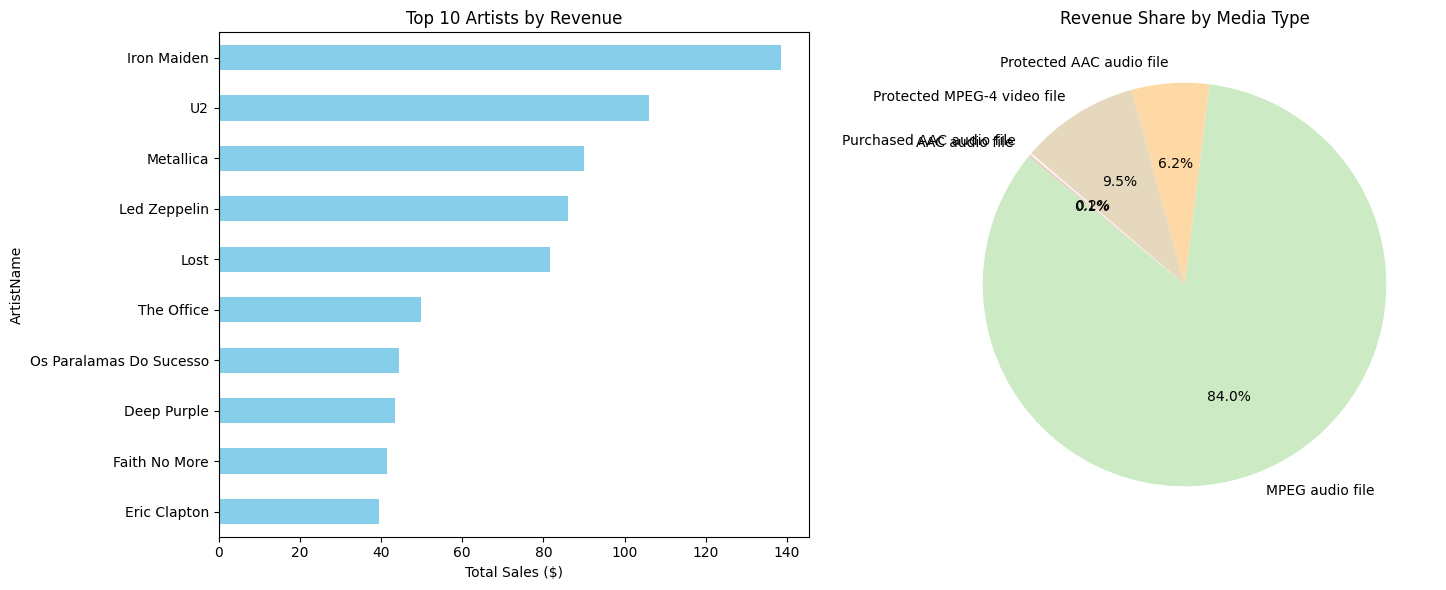

In [ ]:
query = """
SELECT
    e.FirstName || ' ' || e.LastName AS EmployeeName,
    art.Name AS ArtistName,
    mt.Name AS MediaName,
    (il.UnitPrice * il.Quantity) AS LineTotal
FROM employees e
INNER JOIN customers c ON e.EmployeeId = c.SupportRepId
INNER JOIN invoices i ON c.CustomerId = i.CustomerId
INNER JOIN invoice_items il ON i.InvoiceId = il.InvoiceId
INNER JOIN tracks t ON il.TrackId = t.TrackId
INNER JOIN albums alb ON t.AlbumId = alb.AlbumId
INNER JOIN artists art ON alb.ArtistId = art.ArtistId
INNER JOIN media_types mt ON t.MediaTypeId = mt.MediaTypeId;
"""

df = pd.read_sql_query(query, db_con)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Top 10 Artists by Revenue
top_artists = df.groupby('ArtistName')['LineTotal'].sum().sort_values(ascending=True).tail(10)
top_artists.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title('Top 10 Artists by Revenue')
ax1.set_xlabel('Total Sales ($)')

# 2. Revenue Share by Media Type
media_sales = df.groupby('MediaName')['LineTotal'].sum()
media_sales.plot(kind='pie', ax=ax2, autopct='%1.1f%%', cmap='Pastel1', startangle=140)
ax2.set_title('Revenue Share by Media Type')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()



In [ ]:
db_con.close()